In [1]:
# Install libraries 
!pip install seaborn --quiet
!pip install missingno --quiet
!pip install imblearn --quiet
!pip install scikit-learn --quiet

In [2]:
# Import required libraries 
import os 
import sys
import pandas as pd 
import seaborn as sns
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import warnings

sys.path.append(os.path.abspath(".."))

# Import functions 
import functions.wrangling as wrg
import functions.missing_labs as ml
import functions.eda as eda
import functions.eda_model as em

warnings.filterwarnings("ignore")

In [3]:
df_all_vars = ml.load_data("bd_labs_after_cleaned_reduced.csv")
# We standardized the 'PerformedDate' by converting it to a 'VisitOrder' variable—grouping by patient and ordering their lab test records chronologically.
df_all_vars = df_all_vars.sort_values(['Patient_ID', 'PerformedDate'])
df_all_vars['VisitOrder'] = df_all_vars.groupby('Patient_ID').cumcount() + 1

Loaded dataset with shape: (1196, 11)


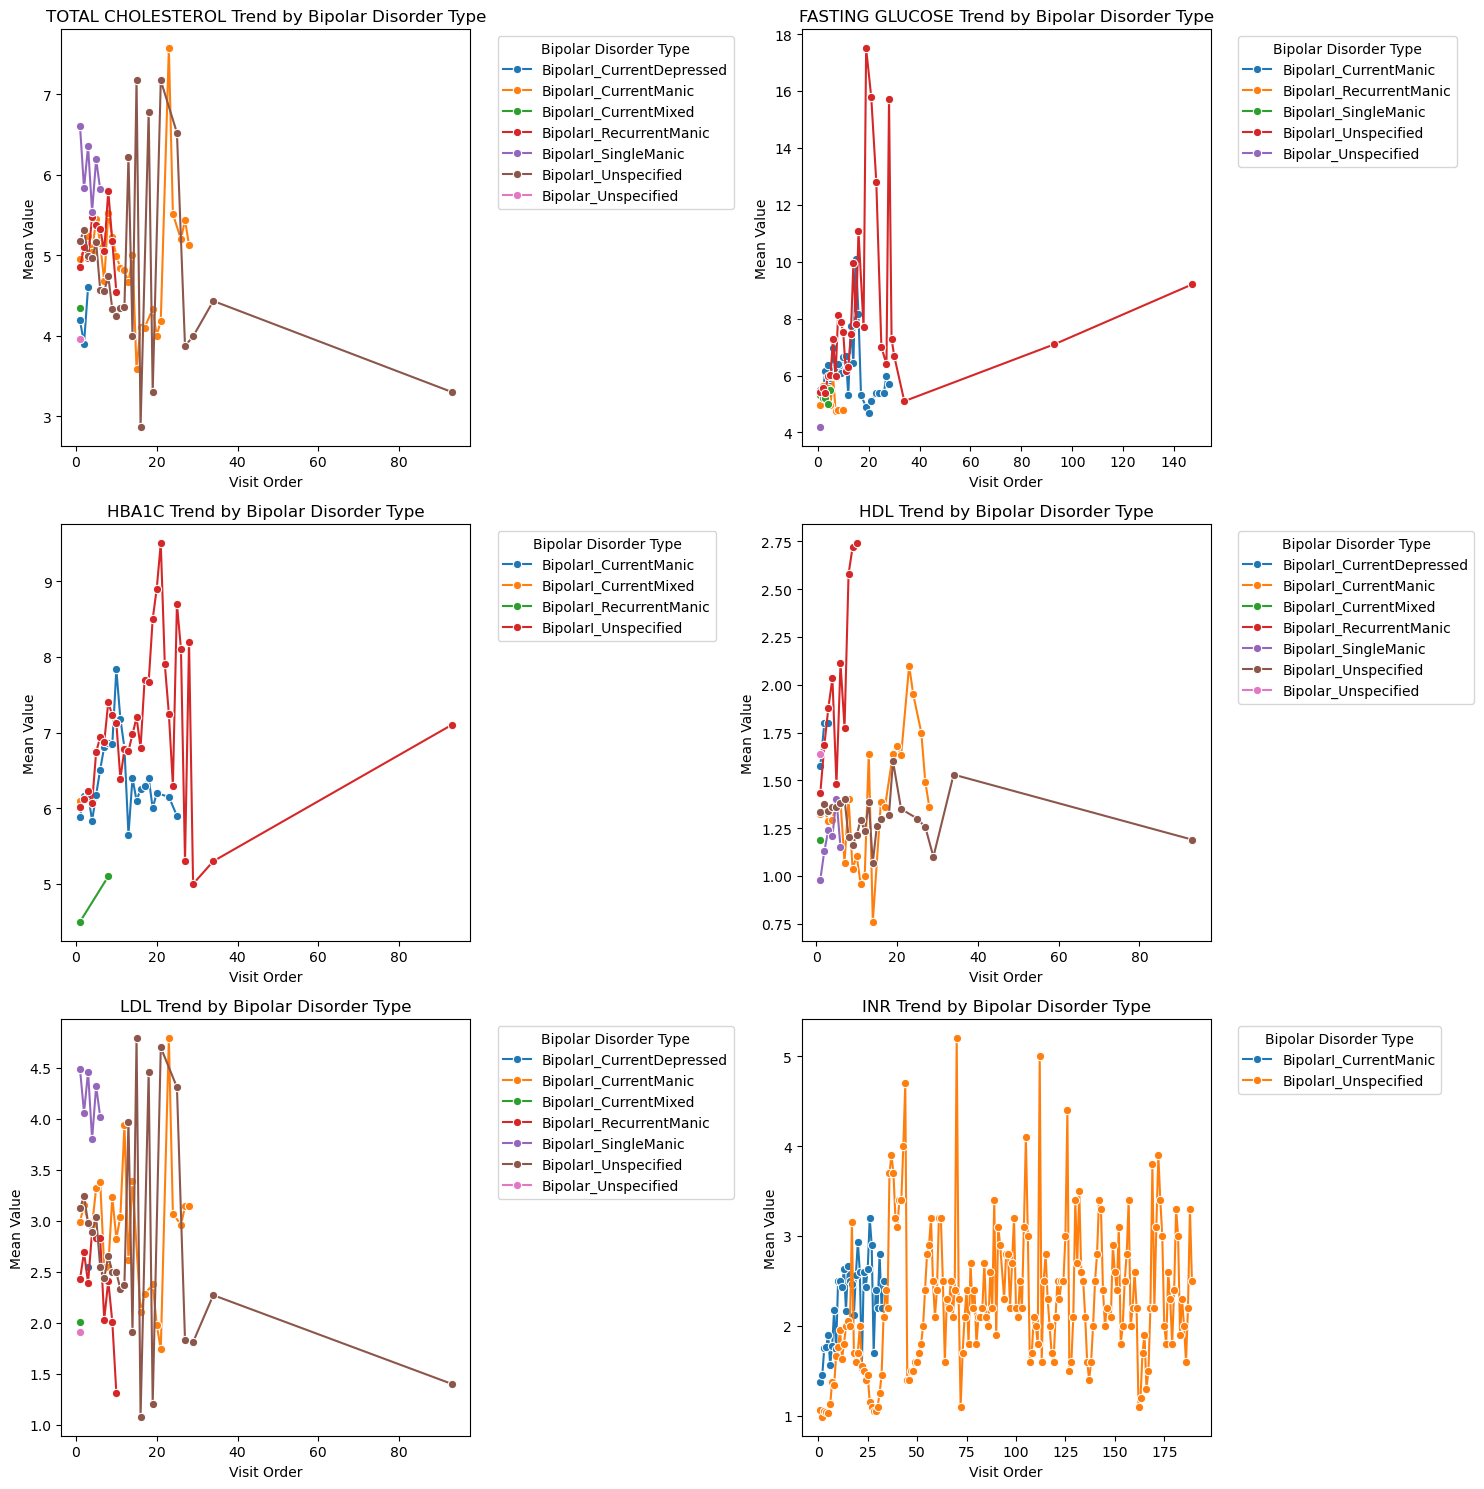

In [4]:
# mapping & encode subtypes of bipolar disorders
bipolar_map = {
    '296.0': 'BipolarI_SingleManic',
    '296.1': 'BipolarI_RecurrentManic',
    '296.4': 'BipolarI_CurrentManic',
    '296.5': 'BipolarI_CurrentDepressed',
    '296.6': 'BipolarI_CurrentMixed',
    '296.7': 'BipolarI_Unspecified',
    '296.8': 'Bipolar_Unspecified'
}

bipolar_order = [
    'BipolarI_SingleManic',
    'BipolarI_RecurrentManic',
    'BipolarI_CurrentManic',
    'BipolarI_CurrentDepressed',
    'BipolarI_CurrentMixed',
    'BipolarI_Unspecified',
    'Bipolar_Unspecified'
]

df_all_vars = em.map_encode(
    data=df_all_vars,
    code='BD_Code',
    mapping_dict=bipolar_map,
    ordered_levels=bipolar_order,
    new_label='Bipolar Disorder Type',
    new_factor='Bipolar Disorder Type Factor',
    new_num='Bipolar Disorder Type Num'
)
# visualize grouped trajctory of subtypes of bipolar disorders
em.plot_grouped_trends(
    data=df_all_vars,
    variables=['TOTAL CHOLESTEROL', 'FASTING GLUCOSE', 'HBA1C', 
            'HDL', 'LDL', 'INR'],
    group_x='VisitOrder',
    group_hue='Bipolar Disorder Type',
    xlabel='Visit Order',
    ylabel='Mean Value',
    title_prefix='',
)

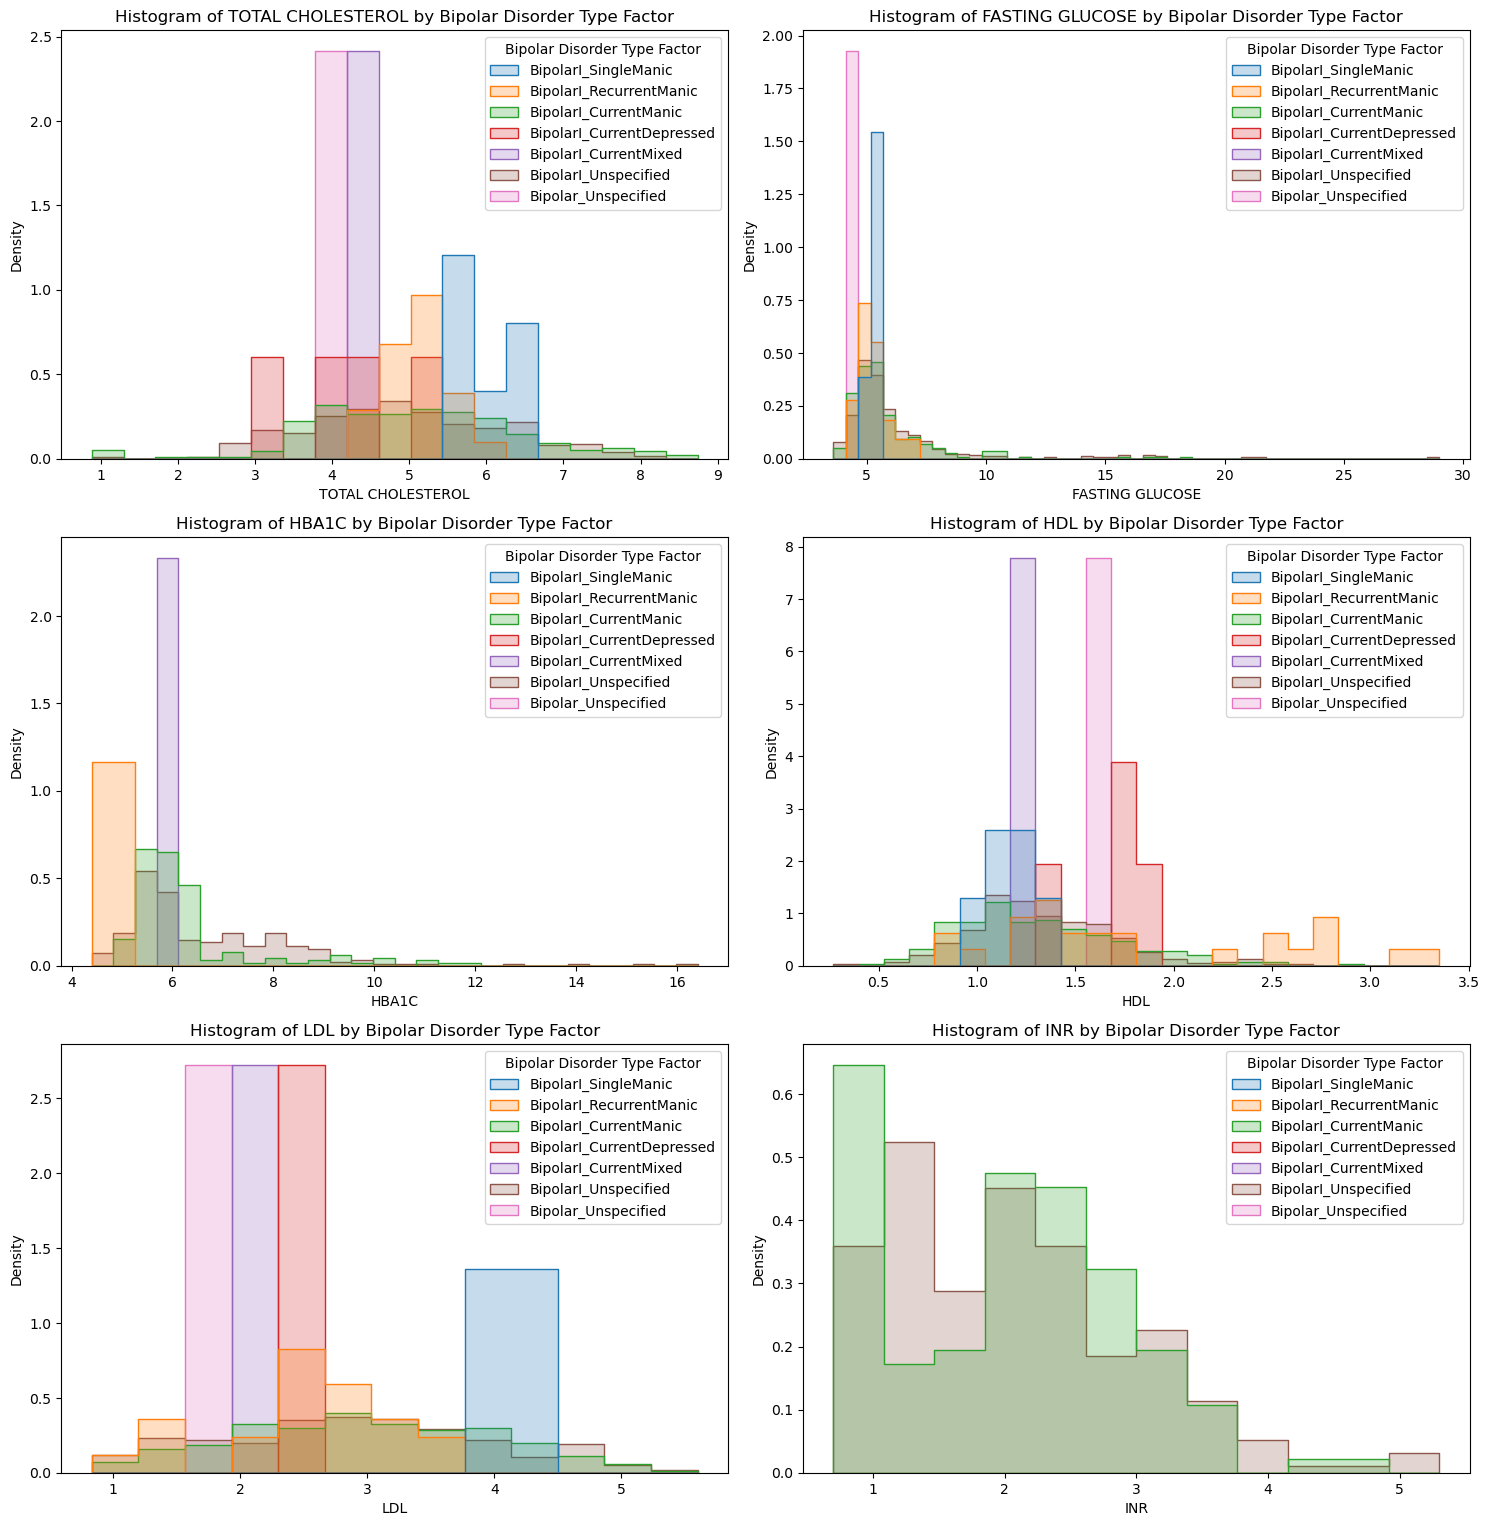

In [5]:
# eda for subtypes of bipolar disorders
em.plot_grouped_histograms(df_all_vars, 
                      variables = ['TOTAL CHOLESTEROL', 'FASTING GLUCOSE', 'HBA1C',
            'HDL', 'LDL', 'INR'], 
                      group='Bipolar Disorder Type Factor')

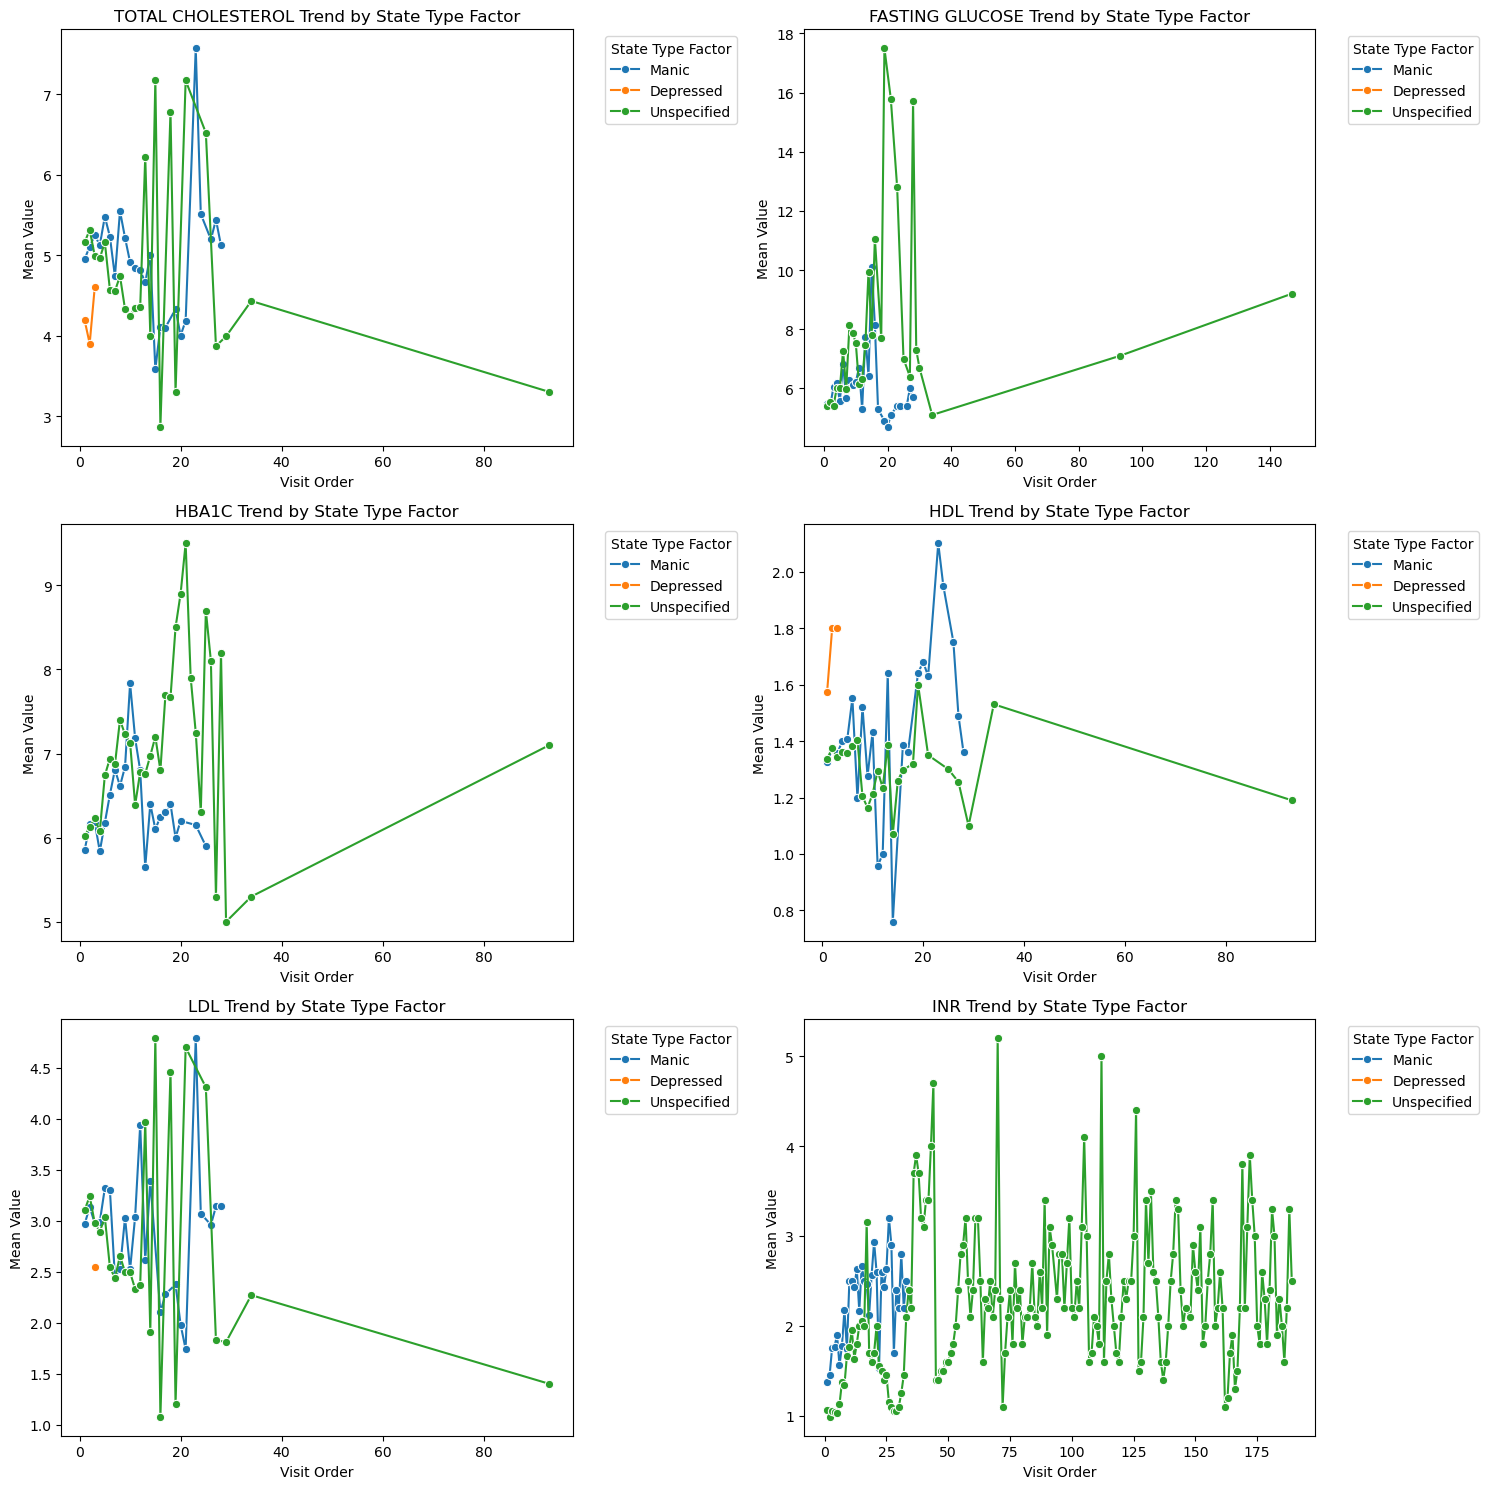

In [6]:
# mapping & encode states of bipolar disorders
state_map = {
    '296.0': 'Manic',         # BipolarI_SingleManic
    '296.1': 'Manic',         # BipolarI_RecurrentManic
    '296.4': 'Manic',         # BipolarI_CurrentManic
    '296.5': 'Depressed',     # BipolarI_CurrentDepressed
    '296.6': 'Manic',         # BipolarI_CurrentMixed (assigned to Manic, can adjust if needed)
    '296.7': 'Unspecified',   # BipolarI_Unspecified
    '296.8': 'Unspecified'    # Bipolar_Unspecified
}

state_order = ['Manic', 'Depressed', 'Unspecified']

df_all_vars = em.map_encode(
    data=df_all_vars,
    code='BD_Code',
    mapping_dict=state_map,
    ordered_levels=state_order,
    new_label='State Type',
    new_factor='State Type Factor',
    new_num='State Type Num'
)
# visualize states of bipolar disorder
em.plot_grouped_trends(
    data=df_all_vars,
    variables=['TOTAL CHOLESTEROL', 'FASTING GLUCOSE', 'HBA1C', 
            'HDL', 'LDL', 'INR'],
    group_x='VisitOrder',
    group_hue='State Type Factor',
    xlabel='Visit Order',
    ylabel='Mean Value',
    title_prefix='',
)


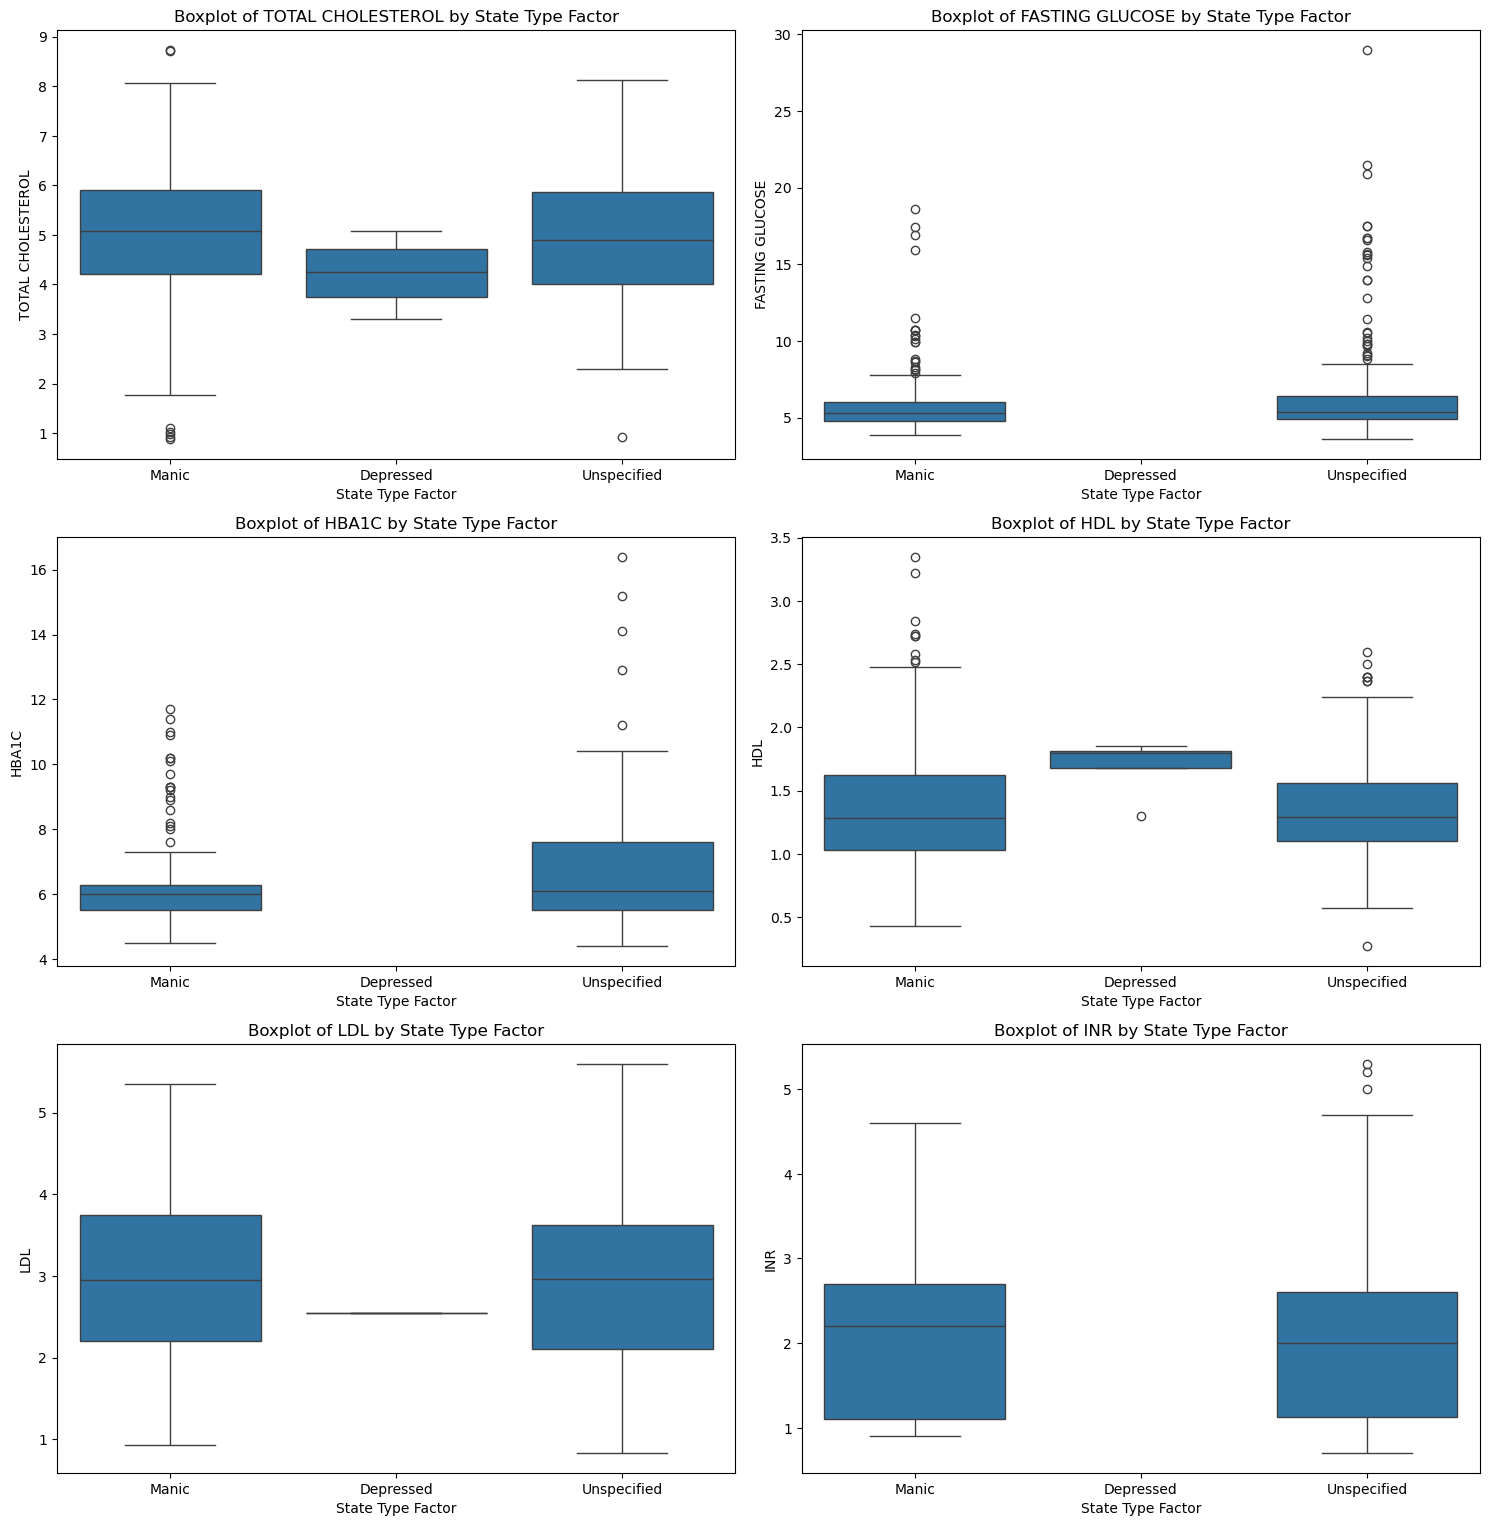

In [7]:
em.plot_grouped_boxplots(df_all_vars, 
                      variables = ['TOTAL CHOLESTEROL', 'FASTING GLUCOSE', 'HBA1C',
            'HDL', 'LDL', 'INR'], 
                      group='State Type Factor')

In [8]:
# Kruskal-Wallis Test to see whether there are significant differences in the variable across multiple State_factor groups.
em.kruskal_test(df_all_vars, 
             variables= ['TOTAL CHOLESTEROL', 'FASTING GLUCOSE', 'HBA1C',
            'HDL', 'LDL', 'INR'], 
             group_col='Bipolar Disorder Type Factor')

TOTAL CHOLESTEROL: H=9.325, p=0.0535
FASTING GLUCOSE: H=3.681, p=0.2981
HBA1C: H=2.178, p=0.1400
HDL: H=19.243, p=0.0007
LDL: H=14.867, p=0.0019
INR: H=0.000, p=0.9882


,variable,n_groups,H_stat,p_value
0,TOTAL CHOLESTEROL,5,9.324590,0.053479
1,FASTING GLUCOSE,4,3.680591,0.298084
2,HBA1C,2,2.177847,0.140010
3,HDL,5,19.242903,0.000704
4,LDL,4,14.866543,0.001934
5,INR,2,0.000219,0.988188


In [9]:
em.kruskal_test(df_all_vars, 
             variables= ['TOTAL CHOLESTEROL', 'FASTING GLUCOSE', 'HBA1C',
            'HDL', 'LDL', 'INR'], 
             group_col='State Type Factor')

TOTAL CHOLESTEROL: H=3.781, p=0.1510
FASTING GLUCOSE: H=2.655, p=0.1032
HBA1C: H=2.720, p=0.0991
HDL: H=4.197, p=0.1226
LDL: H=0.621, p=0.4307
INR: H=0.000, p=0.9882


,variable,n_groups,H_stat,p_value
0,TOTAL CHOLESTEROL,3,3.780509,0.151033
1,FASTING GLUCOSE,2,2.655317,0.103204
2,HBA1C,2,2.720477,0.099068
3,HDL,3,4.197485,0.122611
4,LDL,2,0.620879,0.430721
5,INR,2,0.000219,0.988188


Best Parameters from GridSearchCV:
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best CV Precision (macro): 0.797

 Classification Report:

              precision    recall  f1-score   support

           0       0.97      1.00      0.99       141
           1       0.92      0.98      0.95       141
           2       0.65      0.65      0.65       141
           5       0.67      0.61      0.64       141

    accuracy                           0.81       564
   macro avg       0.80      0.81      0.80       564
weighted avg       0.80      0.81      0.80       564

Confusion Matrix (Raw Counts):

[[141   0   0   0]
 [  0 138   2   1]
 [  3   6  91  41]
 [  1   6  48  86]]


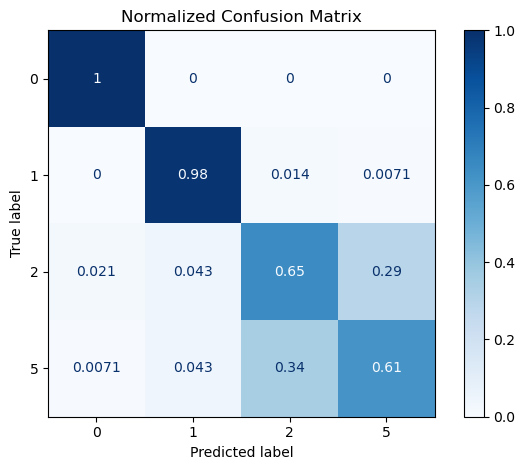

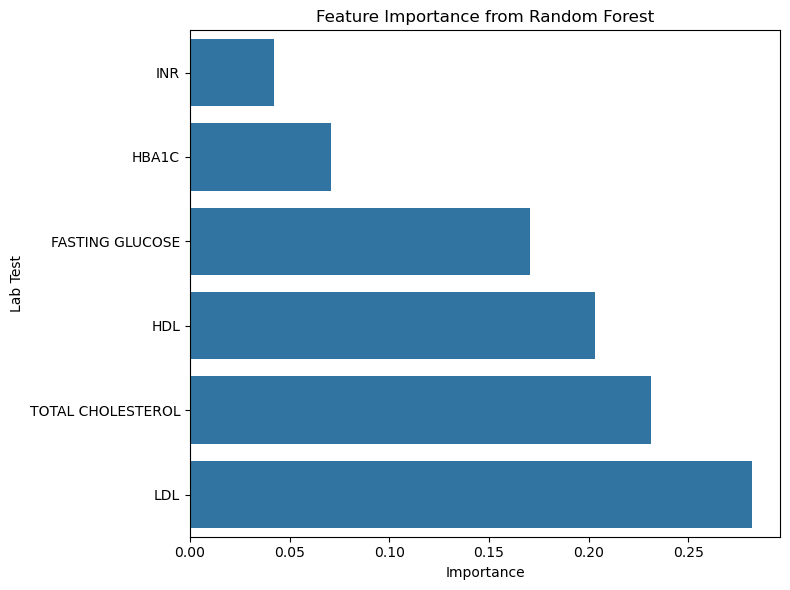


 Cross-Validated Precision (macro): 0.766 ± 0.027


In [10]:
# Random forest

# Define lab test features 
lab_vars = ['TOTAL CHOLESTEROL', 'FASTING GLUCOSE', 'HBA1C', 'HDL', 'LDL', 'INR']
df_clean = df_all_vars.dropna(subset=['Bipolar Disorder Type Factor']).copy()
df_clean['Bipolar Disorder Type Factor'] = pd.Categorical(df_clean['Bipolar Disorder Type Factor']).codes

# Keep only classes with at least 5 samples
class_counts = df_clean['Bipolar Disorder Type Factor'].value_counts()
valid_classes = class_counts[class_counts >= 5].index.tolist()
df_filtered = df_clean[df_clean['Bipolar Disorder Type Factor'].isin(valid_classes)].copy()

# Impute missing lab values with column means
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='mean')
X = imputer.fit_transform(df_filtered[lab_vars])
y = df_filtered['Bipolar Disorder Type Factor'].values

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Balance class distribution using SMOTE 
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)

# Split into train and test sets 
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, stratify=y_resampled, test_size=0.2, random_state=42
)

# Grid search for best hyperparameters
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

grid_search = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    param_grid,
    scoring='precision_macro',
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters from GridSearchCV:")
print(grid_search.best_params_)
print(f"Best CV Precision (macro): {grid_search.best_score_:.3f}")

# Evaluate the final model
best_rf = grid_search.best_estimator_
best_rf.fit(X_train, y_train)
y_pred = best_rf.predict(X_test)

print("\n Classification Report:\n")
print(classification_report(y_test, y_pred, zero_division=0))

print("Confusion Matrix (Raw Counts):\n")
print(confusion_matrix(y_test, y_pred))

# Normalized confusion matrix plot 
ConfusionMatrixDisplay.from_estimator(best_rf, X_test, y_test, cmap="Blues", normalize='true')
plt.title("Normalized Confusion Matrix")
plt.tight_layout()
plt.show()

# Feature importance plot 
importances = pd.Series(best_rf.feature_importances_, index=lab_vars).sort_values(ascending=True)

plt.figure(figsize=(8, 6))
sns.barplot(x=importances.values, y=importances.index)
plt.title("Feature Importance from Random Forest")
plt.xlabel("Importance")
plt.ylabel("Lab Test")
plt.tight_layout()
plt.show()

# Cross-validated precision
cv_scores = cross_val_score(best_rf, X_resampled, y_resampled, cv=5, scoring='precision_macro')
print(f"\n Cross-Validated Precision (macro): {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
